<a href="https://colab.research.google.com/github/amathie5/PPS-Project-/blob/main/pps_project_vgraphiques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

In [ ]:
## Parameters
horizon = 12    #in months
w_i = 90        # Initial number of workers
p = 10          #Production rate per worker per month
inv_i = 900     # Initial inventory
inv_t = 1000    # Final inventory target by end of December
hold = 1000     # Inventory holding cost per watch per month (security/insurance)
wage_r = 7000   # Regular wage/worker/month
hiring = 50000  # Hiring cost per worker
layoff = 25000  # layoff cost per worker
max_overtime = 0.2  # overtime allowance......
overtime_cost = 14000 # 2x wage_r
subcontracting_cost = 15000 # CHF per watch
max_contracting = 300 # watches per month
overtime_months = [3,5,9,12] # march, may, sept, dec
subcontracting_months = [6,7,10,12] # june, july, oct, dec
demand = [900,950,1200,1050,1100,1300,1250,1100,1300,1450,1500,1700]

In [ ]:
pip install pulp numpy pandas matplotlib


In [ ]:
import numpy as np
import pandas as pd

def simulate_plan(strategy):

    months = horizon
    workers = np.zeros(months)
    hired = np.zeros(months)
    fired = np.zeros(months)
    production = np.zeros(months)
    overtime_prod = np.zeros(months) # Nouveau tableau pour l'overtime
    inventory = np.zeros(months+1)
    inventory_cost = hold

    inventory[0] = inv_i

    # ----------------------------
    # LEVEL STRATEGY
    # ----------------------------
    if strategy == "level":

        production_per_month = w_i * p
        workers[:] = w_i

        for t in range(months):

            production[t] = production_per_month
            inventory[t+1] = inventory[t] + production[t] - demand[t]

    # ----------------------------
    # CHASE STRATEGY
    # ----------------------------
    elif strategy == "chase":

        for t in range(months):

            workers_needed = np.ceil(demand[t] / p)
            workers[t] = workers_needed

            if t == 0:
                hired[t] = max(0, workers[t] - w_i)
                fired[t] = max(0, w_i - workers[t])
            else:
                hired[t] = max(0, workers[t] - workers[t-1])
                fired[t] = max(0, workers[t-1] - workers[t])

            production[t] = workers[t] * p
            inventory[t+1] = inventory[t] + production[t] - demand[t]

    # ----------------------------
    # MIXED STRATEGY (Level + Overtime)
    # ----------------------------
    elif strategy == "mixed":

        workers[:] = w_i

        for t in range(months):

            reg_prod = workers[t] * p
            production[t] = reg_prod

            # Calcul du déficit avant l'overtime
            shortage = demand[t] - (inventory[t] + reg_prod)

            # Vérification : a-t-on besoin d'overtime ET est-ce un mois autorisé ? (t+1 car l'index 0 = mois 1)
            if shortage > 0 and (t + 1) in overtime_months:
                max_ot = reg_prod * max_overtime
                ot_used = min(shortage, max_ot)

                overtime_prod[t] = ot_used
                production[t] += ot_used

            inventory[t+1] = inventory[t] + production[t] - demand[t]

    # ----------------------------
    # COSTS
    # ----------------------------

    wage_cost = workers * wage_r
    hiring_cost = hired * hiring
    firing_cost = fired * layoff

    # Coût de l'overtime par unité = coût mensuel de l'overtime / production normale par travailleur
    ot_unit_cost = overtime_cost / p
    ot_cost = overtime_prod * ot_unit_cost

    inventory_cost = inventory[1:] * hold

    total_cost = wage_cost + hiring_cost + firing_cost + inventory_cost + ot_cost

    results = pd.DataFrame({
        "Month": range(1, months+1),
        "Workers": workers,
        "Hired": hired,
        "Fired": fired,
        "Regular Prod": production - overtime_prod,
        "Overtime Prod": overtime_prod,
        "Total Prod": production,
        "Demand": demand,
        "Inventory": inventory[1:],
        "Total Cost": total_cost
    })

    summary = {
        "Total Wage": wage_cost.sum(),
        "Total Hiring": hiring_cost.sum(),
        "Total Layoff": firing_cost.sum(),
        "Total Overtime": ot_cost.sum(),
        "Total Inventory": inventory_cost.sum(),
        "Grand Total": total_cost.sum()
    }

    return results, summary

In [ ]:
#level strategy
level_table, level_cost = simulate_plan("level")

display(level_table)
display(level_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1980000.0
1,2,90.0,0.0,0.0,900.0,0.0,900.0,950,850.0,1905000.0
2,3,90.0,0.0,0.0,900.0,0.0,900.0,1200,550.0,1455000.0
3,4,90.0,0.0,0.0,900.0,0.0,900.0,1050,400.0,1230000.0
4,5,90.0,0.0,0.0,900.0,0.0,900.0,1100,200.0,930000.0
5,6,90.0,0.0,0.0,900.0,0.0,900.0,1300,-200.0,330000.0
6,7,90.0,0.0,0.0,900.0,0.0,900.0,1250,-550.0,-195000.0
7,8,90.0,0.0,0.0,900.0,0.0,900.0,1100,-750.0,-495000.0
8,9,90.0,0.0,0.0,900.0,0.0,900.0,1300,-1150.0,-1095000.0
9,10,90.0,0.0,0.0,900.0,0.0,900.0,1450,-1700.0,-1920000.0


{'Total Wage': np.float64(7560000.0),
 'Total Hiring': np.float64(0.0),
 'Total Layoff': np.float64(0.0),
 'Total Overtime': np.float64(0.0),
 'Total Inventory': np.float64(-10275000.0),
 'Grand Total': np.float64(-2715000.0)}

In [ ]:
chase_table, chase_cost = simulate_plan("chase")

display(chase_table)
display(chase_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1980000.0
1,2,95.0,5.0,0.0,950.0,0.0,950.0,950,900.0,2265000.0
2,3,120.0,25.0,0.0,1200.0,0.0,1200.0,1200,900.0,3440000.0
3,4,105.0,0.0,15.0,1050.0,0.0,1050.0,1050,900.0,2460000.0
4,5,110.0,5.0,0.0,1100.0,0.0,1100.0,1100,900.0,2370000.0
5,6,130.0,20.0,0.0,1300.0,0.0,1300.0,1300,900.0,3260000.0
6,7,125.0,0.0,5.0,1250.0,0.0,1250.0,1250,900.0,2350000.0
7,8,110.0,0.0,15.0,1100.0,0.0,1100.0,1100,900.0,2495000.0
8,9,130.0,20.0,0.0,1300.0,0.0,1300.0,1300,900.0,3260000.0
9,10,145.0,15.0,0.0,1450.0,0.0,1450.0,1450,900.0,3115000.0


{'Total Wage': np.float64(10360000.0),
 'Total Hiring': np.float64(5750000.0),
 'Total Layoff': np.float64(875000.0),
 'Total Overtime': np.float64(0.0),
 'Total Inventory': np.float64(16200000.0),
 'Grand Total': np.float64(33185000.0)}

In [ ]:
mixed_table, mixed_cost = simulate_plan("mixed")
display(mixed_table)
display(mixed_cost)

,Month,Workers,Hired,Fired,Regular Prod,Overtime Prod,Total Prod,Demand,Inventory,Total Cost
0,1,90.0,0.0,0.0,900.0,0.0,900.0,900,900.0,1980000.0
1,2,90.0,0.0,0.0,900.0,0.0,900.0,950,850.0,1905000.0
2,3,90.0,0.0,0.0,900.0,0.0,900.0,1200,550.0,1455000.0
3,4,90.0,0.0,0.0,900.0,0.0,900.0,1050,400.0,1230000.0
4,5,90.0,0.0,0.0,900.0,0.0,900.0,1100,200.0,930000.0
5,6,90.0,0.0,0.0,900.0,0.0,900.0,1300,-200.0,330000.0
6,7,90.0,0.0,0.0,900.0,0.0,900.0,1250,-550.0,-195000.0
7,8,90.0,0.0,0.0,900.0,0.0,900.0,1100,-750.0,-495000.0
8,9,90.0,0.0,0.0,900.0,180.0,1080.0,1300,-970.0,-573000.0
9,10,90.0,0.0,0.0,900.0,0.0,900.0,1450,-1520.0,-1650000.0


{'Total Wage': np.float64(7560000.0),
 'Total Hiring': np.float64(0.0),
 'Total Layoff': np.float64(0.0),
 'Total Overtime': np.float64(504000.0),
 'Total Inventory': np.float64(-8925000.0),
 'Grand Total': np.float64(-861000.0)}

In [ ]:
inventory_cost_values = [200, 500, 800, 1000, 1200, 1500]

level_costs = []
chase_costs = []
mixed_costs = []
for cost in inventory_cost_values:

    hold = cost   # on change le coût d'inventaire

    level_table, level_cost = simulate_plan("level")
    chase_table, chase_cost = simulate_plan("chase")
    mixed_table, mixed_cost = simulate_plan("mixed")

    level_costs.append(level_cost["Grand Total"])
    chase_costs.append(chase_cost["Grand Total"])
    mixed_costs.append(mixed_cost["Grand Total"])

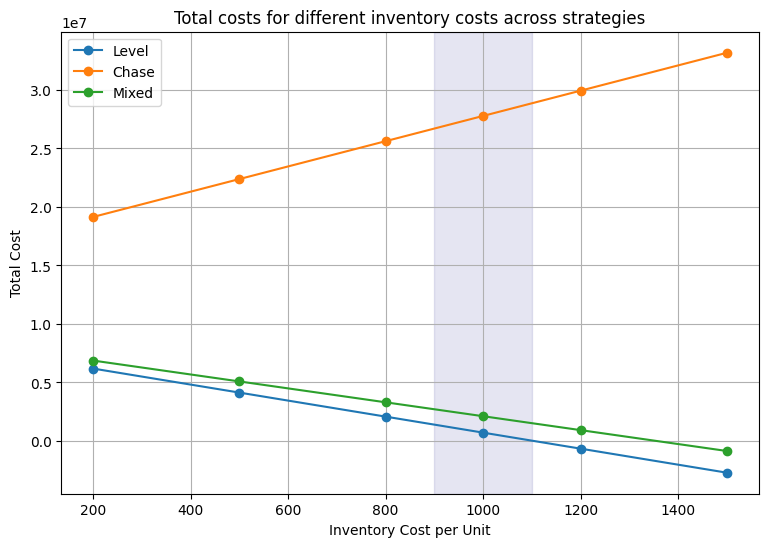

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.plot(inventory_cost_values, level_costs, marker="o", label="Level")
plt.plot(inventory_cost_values, chase_costs, marker="o", label="Chase")
plt.plot(inventory_cost_values, mixed_costs, marker="o", label="Mixed")

plt.xlabel("Inventory Cost per Unit")
plt.ylabel("Total Cost")
plt.title("Total costs for different inventory costs across strategies")
plt.axvspan(900,1100, color="navy", alpha=0.1)

plt.legend()
plt.grid(True)

plt.show()

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

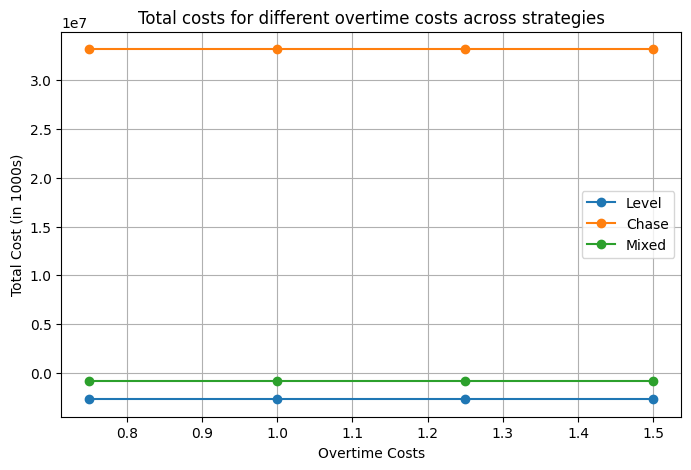

In [ ]:
#Graphique Overtime Cost
overtime_values = [0.75, 1.0, 1.25, 1.5]
level_ot = []
chase_ot = []
mixed_ot = []
for ot in overtime_values:

    overtime_wage_multiplier = ot

    level_table, level_cost = simulate_plan("level")
    chase_table, chase_cost = simulate_plan("chase")
    mixed_table, mixed_cost = simulate_plan("mixed")

    level_ot.append(level_cost["Grand Total"])
    chase_ot.append(chase_cost["Grand Total"])
    mixed_ot.append(mixed_cost["Grand Total"])
    plt.figure(figsize=(8,5))

plt.plot(overtime_values, level_ot, marker='o', label="Level")
plt.plot(overtime_values, chase_ot, marker='o', label="Chase")
plt.plot(overtime_values, mixed_ot, marker='o', label="Mixed")

plt.xlabel("Overtime Costs")
plt.ylabel("Total Cost (in 1000s)")
plt.title("Total costs for different overtime costs across strategies")

plt.legend()
plt.grid(True)

plt.show()

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

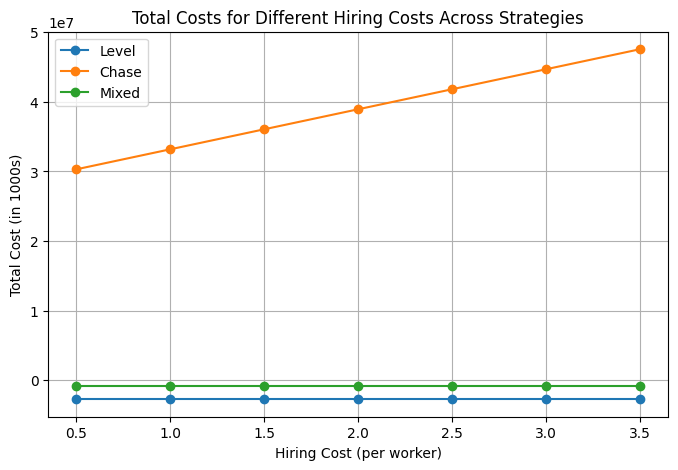

In [ ]:
#hiring value
hiring_values = [0.5,1,1.5,2,2.5,3,3.5]
level_hire = []
chase_hire = []
mixed_hire = []
for h in hiring_values:

    hiring = h * 50000

    level_table, level_cost = simulate_plan("level")
    chase_table, chase_cost = simulate_plan("chase")
    mixed_table, mixed_cost = simulate_plan("mixed")

    level_hire.append(level_cost["Grand Total"])
    chase_hire.append(chase_cost["Grand Total"])
    mixed_hire.append(mixed_cost["Grand Total"])
    plt.figure(figsize=(8,5))

plt.plot(hiring_values, level_hire, marker='o', label="Level")
plt.plot(hiring_values, chase_hire, marker='o', label="Chase")
plt.plot(hiring_values, mixed_hire, marker='o', label="Mixed")

plt.xlabel("Hiring Cost (per worker)")
plt.ylabel("Total Cost (in 1000s)")
plt.title("Total Costs for Different Hiring Costs Across Strategies")

plt.legend()
plt.grid(True)

plt.show()


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

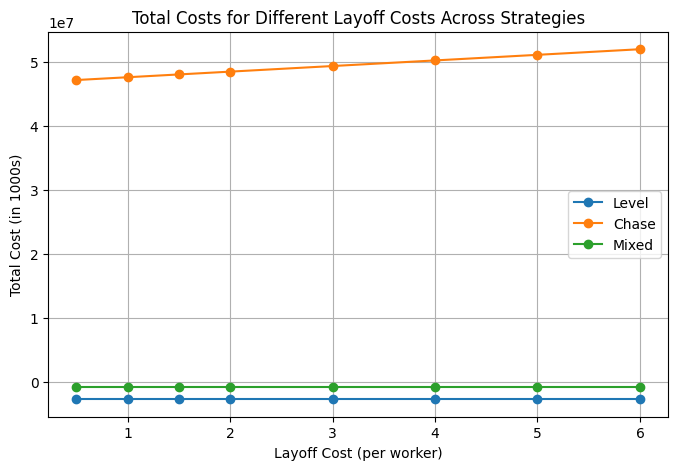

In [ ]:
#layoff cost
layoff_values = [0.5,1,1.5,2,3,4,5,6]
level_lay = []
chase_lay = []
mixed_lay = []
for l in layoff_values:

    layoff = l * 25000

    level_table, level_cost = simulate_plan("level")
    chase_table, chase_cost = simulate_plan("chase")
    mixed_table, mixed_cost = simulate_plan("mixed")

    level_lay.append(level_cost["Grand Total"])
    chase_lay.append(chase_cost["Grand Total"])
    mixed_lay.append(mixed_cost["Grand Total"])
    plt.figure(figsize=(8,5))

plt.plot(layoff_values, level_lay, marker='o', label="Level")
plt.plot(layoff_values, chase_lay, marker='o', label="Chase")
plt.plot(layoff_values, mixed_lay, marker='o', label="Mixed")

plt.xlabel("Layoff Cost (per worker)")
plt.ylabel("Total Cost (in 1000s)")
plt.title("Total Costs for Different Layoff Costs Across Strategies")

plt.legend()
plt.grid(True)

plt.show()

# Part 2

In [ ]:
!pip install pulp

In [ ]:
from pulp import LpProblem, LpMinimize, LpVariable, lpSum, LpInteger, LpContinuous, value, LpStatus
import numpy as np
import pandas as pd

In [ ]:
import numpy as np
import pandas as pd
from pulp import *

def solve_lp_basicaggregate(
    demand,
    production_per_worker,
    starting_inventory,
    desired_ending_inventory,
    initial_workers,
    wage_per_worker,
    hire_cost,
    layoff_cost,
    inventory_cost_per_unit
):

    months = len(demand)

    # Create MILP model
    model = LpProblem("Aggregate_Production_Planning_Model1", LpMinimize)

    # Decision variables
    W = LpVariable.dicts("Workers", range(months), lowBound=0, cat=LpInteger)
    H = LpVariable.dicts("Hired", range(months), lowBound=0, cat=LpInteger)
    F = LpVariable.dicts("Fired", range(months), lowBound=0, cat=LpInteger)
    P = LpVariable.dicts("Production", range(months), lowBound=0)
    I = LpVariable.dicts("Inventory", range(months), lowBound=0)

    # Objective function
    model += lpSum(
        W[t] * wage_per_worker +
        H[t] * hire_cost +
        F[t] * layoff_cost +
        I[t] * inventory_cost_per_unit
        for t in range(months)
    )

    # Constraints
    for t in range(months):

        # Production capacity
        model += P[t] == W[t] * production_per_worker

        if t == 0:
            # Workforce evolution
            model += W[t] == initial_workers + H[t] - F[t]

            # Inventory balance
            model += I[t] == starting_inventory + P[t] - demand[t]

        else:
            model += W[t] == W[t-1] + H[t] - F[t]
            model += I[t] == I[t-1] + P[t] - demand[t]

    # Final inventory requirement
    model += I[months-1] == desired_ending_inventory

    # Solve
    model.solve()

    status = LpStatus[model.status]
    objective = value(model.objective)

    # Create results table
    results = pd.DataFrame({
        "Month": np.arange(1, months+1),
        "Workers": [W[t].varValue for t in range(months)],
        "Hired": [H[t].varValue for t in range(months)],
        "Fired": [F[t].varValue for t in range(months)],
        "Produced": [P[t].varValue for t in range(months)],
        "Demand": demand,
        "End Inventory": [I[t].varValue for t in range(months)]
    })

    summary = {
        "Status": status,
        "Total Cost": objective
    }

    return results, summary

In [ ]:
demand = [900,950,1200,1050,1100,1300,1250,1100,1300,1450,1500,1700]

model1_table, model1_summary = solve_lp_basicaggregate(
    demand=demand,
    production_per_worker=10,
    starting_inventory=900,
    desired_ending_inventory=1000,
    initial_workers=90,
    wage_per_worker=7000,
    hire_cost=50000,
    layoff_cost=25000,
    inventory_cost_per_unit=1000
)

display(model1_table)
display(model1_summary)

,Month,Workers,Hired,Fired,Produced,Demand,End Inventory
0,1,80.0,0.0,10.0,800.0,900,800.0
1,2,80.0,0.0,0.0,800.0,950,650.0
2,3,80.0,0.0,0.0,800.0,1200,250.0
3,4,80.0,0.0,0.0,800.0,1050,0.0
4,5,115.0,35.0,0.0,1150.0,1100,50.0
5,6,125.0,10.0,0.0,1250.0,1300,0.0
6,7,125.0,0.0,0.0,1250.0,1250,0.0
7,8,125.0,0.0,0.0,1250.0,1100,150.0
8,9,125.0,0.0,0.0,1250.0,1300,100.0
9,10,185.0,60.0,0.0,1850.0,1450,500.0


{'Status': 'Optimal', 'Total Cost': 20280000.0}